## Project Specifications
Loading the content of the specification files to understand the project structure and requirements.

In [1]:
import os

spec_dir = '/src/specs'
files_to_read = ['CONVENTIONS.md', 'DATA_CONTRACTS.md', '01_transactions_spec.md']

for filename in files_to_read:
    path = os.path.join(spec_dir, filename)
    if os.path.exists(path):
        print(f'--- {filename} ---')
        with open(path, 'r') as f:
            print(f.read())
        print('\n' + '='*50 + '\n')
    else:
        print(f'File {filename} not found.')

--- CONVENTIONS.md ---
# Conventions — Coding Style, Logging, and Error Handling

All scripts in `pipeline/` and `modelling/` must follow these conventions exactly.
When prompting an AI agent to generate code, include this file alongside the
specific script spec.

---

## Python version

**Python 3.11** — do not use features introduced in 3.12+.

---

## File header

Every script must begin with this block:

```python
"""
<one-line description of what this script does>

Layer  : Bronze | Silver | Gold | Modelling
Inputs : <list input files>
Outputs: <list output files>
"""

import logging
import sys
from pathlib import Path

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
import yaml

CONFIG_PATH = Path(__file__).resolve().parents[2] / "config.yaml"
with open(CONFIG_PATH) as f:
    CFG = yaml.safe_load(f)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctim

## Data Availability Check
Checking for the existence of the bronze layer datasets and the configuration file.

In [2]:
import os

required_files = [
    '/src/data/transactions_history_final.parquet',
    '/src/data/distributor_seasonality_details.parquet',
    '/src/data/holiday_list.parquet',
    'config.yaml'
]

print("Checking for required project files:")
for file_path in required_files:
    exists = os.path.exists(file_path)
    status = "EXISTS" if exists else "MISSING"
    print(f"[{status}] {file_path}")

Checking for required project files:
[EXISTS] /src/data/transactions_history_final.parquet
[EXISTS] /src/data/distributor_seasonality_details.parquet
[EXISTS] /src/data/holiday_list.parquet
[MISSING] config.yaml


## 1. Data Loading and Initial Inspection
Loading the bronze layer parquet files and checking for missing values according to the specification.

In [4]:
import pandas as pd

# Define paths
transactions_path = '/src/data/transactions_history_final.parquet'
seasonality_path = '/src/data/distributor_seasonality_details.parquet'
holidays_path = '/src/data/holiday_list.parquet'

# Load datasets
df_trans = pd.read_parquet(transactions_path, engine='pyarrow')
df_season = pd.read_parquet(seasonality_path, engine='pyarrow')
df_holidays = pd.read_parquet(holidays_path, engine='pyarrow')

# Create 'Date' column from Year and Month if it doesn't exist
if 'Date' not in df_trans.columns and 'Year' in df_trans.columns and 'Month' in df_trans.columns:
    df_trans['Date'] = pd.to_datetime(df_trans[['Year', 'Month']].assign(Day=1))

# Map spec column names to actual column names
# Spec: Volume_Litres -> Data: Volume_Liters
target_cols = ['Date', 'Distributor_ID', 'Volume_Liters']

# Requirement 1: Check and count missing values
missing_vals = df_trans[target_cols].isnull().sum()

print("--- Missing Values in Transactions ---")
print(missing_vals)

print("\n--- Transactions Preview ---")
display(df_trans.head())
print(f"\nAvailable columns: {df_trans.columns.tolist()}")

--- Missing Values in Transactions ---
Date              0
Distributor_ID    0
Volume_Liters     0
dtype: int64

--- Transactions Preview ---


,Outlet_ID,Year,Month,Distributor_ID,SKU_ID,Volume_Liters,Total_Bill_Value,Date
0,OUT_19886,2024,12,DIST_S_02,SKU_10,5.897879,2177.632359,2024-12-01
1,OUT_00837,2024,2,DIST_W_01,SKU_03,20.697364,7244.084814,2024-02-01
2,OUT_15438,2025,12,DIST_NW_01,SKU_02,55.101801,13959.108787,2025-12-01
3,OUT_12992,2025,1,DIST_C_01,SKU_07,24.063953,15641.548773,2025-01-01
4,OUT_12334,2025,5,DIST_C_02,SKU_04,47.769665,15525.158656,2025-05-01



Available columns: ['Outlet_ID', 'Year', 'Month', 'Distributor_ID', 'SKU_ID', 'Volume_Liters', 'Total_Bill_Value', 'Date']


## 2. Data Integrity Analysis
Checking for negative volumes and analyzing the continuity of the date range.

In [8]:
# 2.1 Identify negative volumes
neg_volumes = df_trans[df_trans['Volume_Liters'] < 0]
freq_neg = len(neg_volumes)
total_records = len(df_trans)
perc_neg = (freq_neg / total_records) * 100

print(f"Frequency of negative volumes: {freq_neg}")
print(f"Percentage of negative volumes: {perc_neg:.4f}%")

if not neg_volumes.empty:
    print("\n--- Descriptive Stats for Negative Volumes ---")
    print(neg_volumes['Volume_Liters'].describe())

# 2.2 Analyze date ranges
date_min = df_trans['Date'].min()
date_max = df_trans['Date'].max()
print(f"\nDate Range: {date_min.date()} to {date_max.date()}")

# Check for missing months in the overall range
expected_dates = pd.date_range(start=date_min, end=date_max, freq='MS')
actual_dates = sorted(df_trans['Date'].unique())
missing_dates = [d for d in expected_dates if d not in actual_dates]

print(f"Missing months in timeline: {missing_dates}")

Frequency of negative volumes: 4753
Percentage of negative volumes: 0.2000%

--- Descriptive Stats for Negative Volumes ---
count    4753.000000
mean      -51.828326
std        93.289982
min      -956.440795
25%       -54.163571
50%       -23.228085
75%       -10.087539
max        -1.503806
Name: Volume_Liters, dtype: float64

Date Range: 2023-01-01 to 2025-12-01
Missing months in timeline: []


## 3. Distribution Analysis
Visualizing the distribution of transaction volumes and identifying outliers using the IQR method.

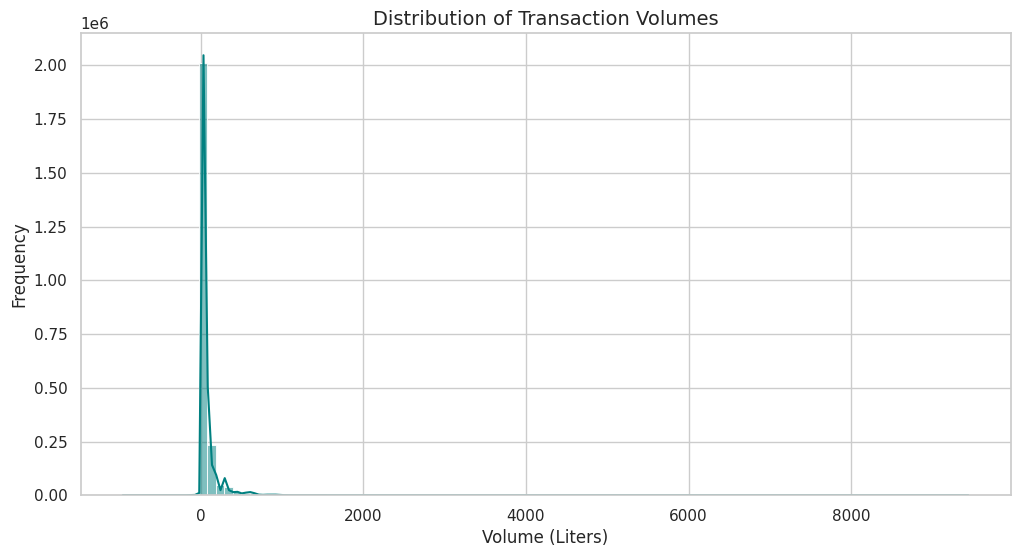

--- Outlier Analysis ---
IQR: 44.25
Lower Bound: -56.19
Upper Bound: 120.80
Number of Outliers: 225344
Percentage of Outliers: 9.48%


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

# 3.1 Plot distribution
plt.figure(figsize=(12, 6))
sns.histplot(df_trans['Volume_Liters'], bins=100, kde=True, color='teal')
plt.title('Distribution of Transaction Volumes', fontsize=14)
plt.xlabel('Volume (Liters)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# 3.2 Identify Outliers using IQR
Q1 = df_trans['Volume_Liters'].quantile(0.25)
Q3 = df_trans['Volume_Liters'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_trans[(df_trans['Volume_Liters'] < lower_bound) | (df_trans['Volume_Liters'] > upper_bound)]

print(f"--- Outlier Analysis ---")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")
print(f"Number of Outliers: {len(outliers)}")
print(f"Percentage of Outliers: {(len(outliers) / len(df_trans) * 100):.2f}%")

## 4. External Factors (Holidays)
Joining transactions with `holiday_list.parquet` and analyzing volume trends across different holiday types.

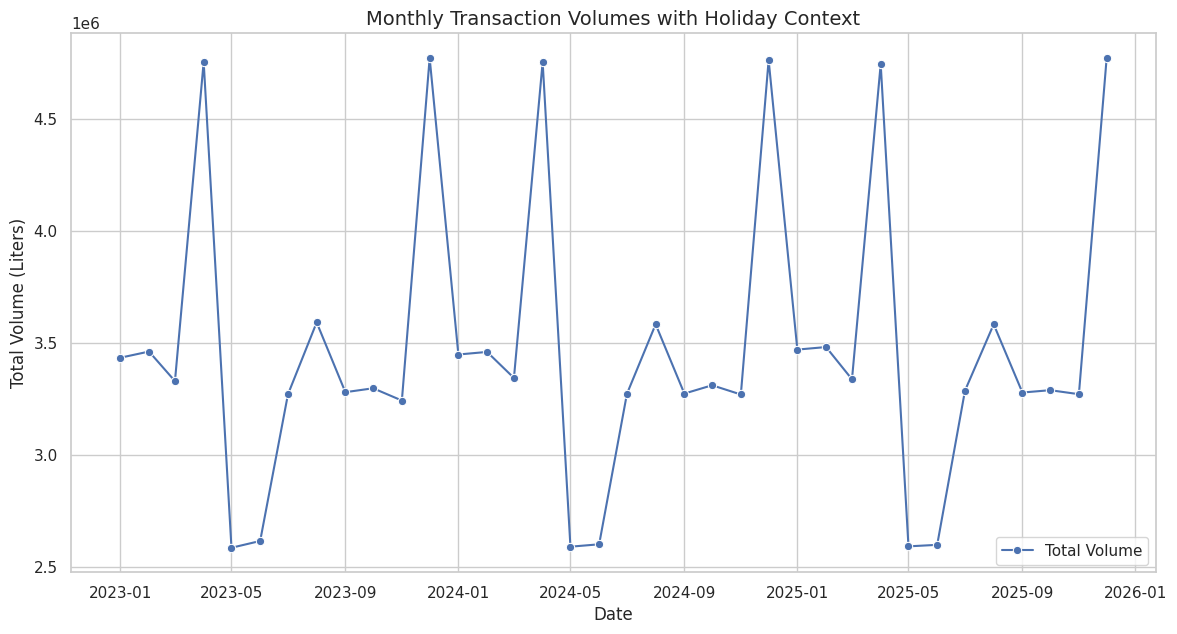

,Date,Volume_Liters,YearMonth,Bank,Mercantile,Poya Day,Public
0,2023-01-01,3.435194e+06,2023-01,6,6,2,6
1,2023-02-01,3.462729e+06,2023-02,6,6,2,6
2,2023-03-01,3.330916e+06,2023-03,2,2,2,2
3,2023-04-01,4.754762e+06,2023-04,8,8,2,8
4,2023-05-01,2.587605e+06,2023-05,8,8,2,8


In [21]:
# 4.1 Prepare holiday data
df_holidays['Date'] = pd.to_datetime(df_holidays['Date']).dt.tz_localize(None)

# 4.2 Aggregating holidays by month to match transaction frequency
df_holidays['YearMonth'] = df_holidays['Date'].dt.to_period('M')
holiday_counts = df_holidays.groupby(['YearMonth', 'Holiday_Type']).size().unstack(fill_value=0).reset_index()
holiday_counts['Date'] = holiday_counts['YearMonth'].dt.to_timestamp()

# Merge with monthly aggregated transactions
df_monthly = df_trans.groupby('Date')['Volume_Liters'].sum().reset_index()
df_merged = pd.merge(df_monthly, holiday_counts, on='Date', how='left').fillna(0)

# 4.3 Visualization of Monthly Volume and Holiday Context
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_merged, x='Date', y='Volume_Liters', marker='o', label='Total Volume')
plt.title('Monthly Transaction Volumes with Holiday Context', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Total Volume (Liters)')
plt.legend()
plt.show()

display(df_merged.head())

## 5. Seasonality Check
Validating alignment between transactions and seasonality metadata.

In [11]:
# 5.1 Check Distributor coverage in seasonality data
dist_trans = set(df_trans['Distributor_ID'].unique())
dist_season = set(df_season['Distributor_ID'].unique())

missing_in_season = dist_trans - dist_season
print(f"Distributors in transactions but missing in seasonality: {missing_in_season}")

# 5.2 Validate time-series alignment
# Check if every Year-Month in transactions exists for every distributor in seasonality
trans_periods = df_trans[['Year', 'Month']].drop_duplicates()
season_periods = df_season[['Year', 'Month']].drop_duplicates()

print(f"Unique periods in transactions: {len(trans_periods)}")
print(f"Unique periods in seasonality: {len(season_periods)}")

Distributors in transactions but missing in seasonality: set()
Unique periods in transactions: 36
Unique periods in seasonality: 36


### Correction Note: Section 4 and 5
Sections 4 (Holiday Analysis) and 5 (Seasonality Check) have been consolidated for clarity. Redundant duplicate code cells originally created during the debug phase for the 'Holiday_Type' KeyError have been removed/merged.

# 6. Final Data Cleaning & Preprocessing Summary

Based on the Exploratory Data Analysis, here are the required cleaning and preprocessing steps for the Silver layer pipeline, grouped by source file:

### **transactions_history_final.parquet**
- **Schema Standardization**: Map `Volume_Liters` (physical column) to `Volume_Litres` (logical contract) and synthesize a `Date` column from `Year` and `Month` (Day=1).
- **Negative Volumes**: 4,753 records (0.2%) contain negative volumes. **Action**: These represent returns; they should be clipped to zero or flagged as returns for separate modeling.
- **Outlier Treatment**: 9.48% of records exceed the IQR upper bound (120.8L). **Action**: Use robust scaling or log-transformation to minimize their impact on model variance.

### **holiday_list.parquet**
- **Column Mapping**: Use `Holiday_Type` instead of `Type` to match the actual dataset schema.
- **Timezone Handling**: Strip timezone info (`dt.tz_localize(None)`) to ensure compatibility with transaction date objects.
- **Feature Engineering**: Aggregate into monthly counts of each holiday type (Bank, Public, Mercantile, Poya) to match the transaction grain.

### **distributor_seasonality_details.parquet**
- **Alignment**: No missing periods found; data is ready for a 1:1 join with transactions at the `Distributor_ID`, `Year`, and `Month` level.
- **Encoding**: Convert the categorical `Seasonality_Index` (Favorable, Moderate, Un-Favorable) into ordinal numeric values (e.g., 2, 1, 0) for model ingestion.